# Statistical Arbitrage Experiment 1 — Predicted Volatility Overlay

## Goal

This notebook studies how a volatility signal should be used in a basis mean-reversion strategy.

We compare several approaches:

1. **No filter**: baseline basis z-score strategy  
2. **Hard filter**: suppress trading when volatility is high  
3. **Soft scaling**: reduce position size as volatility rises  
4. **High-vol only**: only allow trading in high-volatility regimes  
5. **High-vol scaling**: increase position size when volatility is high  

The main question is:

> Is predicted volatility better used as a risk-suppression filter, or as a regime-activation signal?

---

## Experiment structure

- Build `df_mkt` from spot and futures buckets
- Add historical volatility
- Merge predicted volatility from the vol-model notebook
- Compare baseline / historical-vol filter / predicted-vol filter
- Run decile analysis
- Test soft scaling
- Test high-vol-only and high-vol-scaling variants

---

## Main research question

The most important hypothesis in this notebook is:

- A naive intuition says high volatility is dangerous and should be filtered out.
- But for a basis mean-reversion strategy, high-volatility or high-basis-activity regimes may actually create stronger reversion opportunities.

This notebook tests that idea systematically.

In [10]:
import os
import glob
import math
from typing import Optional, List, Dict, Tuple

import numpy as np
import pandas as pd


# =========================================================
# 1) Helpers: load parquet days
# =========================================================

def _date_range_yyyymmdd(start_date: str, end_date: str) -> List[str]:
    dates = pd.date_range(start=pd.Timestamp(start_date), end=pd.Timestamp(end_date), freq="D")
    return [d.strftime("%Y%m%d") for d in dates]


def load_bucket_range(
    buckets_root: str,
    freq_min: int,
    start_date: str,
    end_date: str,
    mid_col_prefer: str = "mid_last",
    px_fallback_col: str = "px_last",
    prefix: str = "spot",
) -> pd.DataFrame:
    """
    Load bucket parquet files over date range and return a standardized dataframe.

    Expected bucket path:
      {buckets_root}/freq={freq_min}min/date=YYYYMMDD/buckets.parquet
    """
    dates = _date_range_yyyymmdd(start_date, end_date)

    frames = []
    for d in dates:
        path = os.path.join(buckets_root, f"freq={freq_min}min", f"date={d}", "buckets.parquet")
        if not os.path.exists(path):
            continue
        df = pd.read_parquet(path)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No bucket parquet files found under {buckets_root} for [{start_date}, {end_date}]")

    df = pd.concat(frames, ignore_index=True)
    df = df.sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)

    # Standardize price column
    px = df[mid_col_prefer].copy() if mid_col_prefer in df.columns else pd.Series(np.nan, index=df.index)
    if px_fallback_col in df.columns:
        px = px.fillna(df[px_fallback_col])
    px = px.ffill()

    out = pd.DataFrame({
        "timestamp": pd.to_datetime(df["timestamp"], utc=True),
        f"{prefix}_mid": px.astype(float),
    })

    # Keep extra cols if present
    extra_cols = [
        "mid_last",
        "px_last",
        "vol_notional",
        "n_trades",
        "buy_ratio",
        "rel_spread_mean",
        "imbalance_mean",
    ]
    for c in extra_cols:
        if c in df.columns:
            out[f"{prefix}_{c}"] = df[c].values

    return out


# =========================================================
# 2) Build spot/futures merged basis dataframe
# =========================================================

def prepare_basis_dataframe(
    spot_buckets_root: str,
    fut_buckets_root: str,
    freq_min: int,
    start_date: str,
    end_date: str,
) -> pd.DataFrame:
    spot = load_bucket_range(
        spot_buckets_root, freq_min, start_date, end_date,
        mid_col_prefer="mid_last", px_fallback_col="px_last", prefix="spot"
    )
    fut = load_bucket_range(
        fut_buckets_root, freq_min, start_date, end_date,
        mid_col_prefer="mid_last", px_fallback_col="px_last", prefix="fut"
    )

    df = pd.merge(spot, fut, on="timestamp", how="inner")
    df = df.sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)

    # log prices and returns
    df["log_spot"] = np.log(df["spot_mid"].replace(0, np.nan))
    df["log_fut"] = np.log(df["fut_mid"].replace(0, np.nan))
    df["spot_ret"] = df["log_spot"].diff()
    df["fut_ret"] = df["log_fut"].diff()

    # basis and basis return
    df["basis"] = df["log_fut"] - df["log_spot"]
    df["basis_ret"] = df["basis"].diff()

    return df


# =========================================================
# 3) Historical vol signal
# =========================================================

def add_historical_vol_signal(
    df: pd.DataFrame,
    freq_min: int = 1,
    horizon_min: int = 30,
    ret_col: str = "spot_ret",
    out_col: str = "hist_vol_spot_30m",
) -> pd.DataFrame:
    """
    Historical realized vol over past horizon_min minutes:
      sqrt(sum ret^2 over past window)
    """
    out = df.copy()
    W = int(round(horizon_min / freq_min))
    out[out_col] = np.sqrt(out[ret_col].pow(2).rolling(W, min_periods=W).sum())
    return out


# =========================================================
# 4) Merge predicted vol signal from previous notebook
# =========================================================

def merge_predicted_vol_signal(
    df: pd.DataFrame,
    pred_df: pd.DataFrame,
    pred_col: str = "pred_y_30m",
    out_col: str = "pred_vol_spot_30m",
) -> pd.DataFrame:
    """
    pred_df expected columns:
      timestamp, pred_y_30m
    where pred_y_30m is log future RV prediction from previous notebook.

    Convert to level vol-like signal:
      exp(pred_y_30m / 2)
    """
    out = df.copy()

    p = pred_df.copy()
    p["timestamp"] = pd.to_datetime(p["timestamp"], utc=True)
    p = p.sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last")

    # If the prediction is in log-RV space, convert to vol scale
    p[out_col] = np.exp(p[pred_col] / 2.0)

    out = pd.merge(out, p[["timestamp", out_col]], on="timestamp", how="left")
    return out


# =========================================================
# 5) Baseline / filtered strategy
# =========================================================

def run_basis_zscore_strategy(
    df: pd.DataFrame,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    vol_signal_col: Optional[str] = None,
    vol_filter_quantile: Optional[float] = None,
    vol_filter_lookback_min: int = 30 * 24 * 60,
) -> pd.DataFrame:
    """
    Simple basis mean-reversion strategy.

    position:
      +1 = long futures / short spot   (basis expected to rise)
      -1 = short futures / long spot   (basis expected to fall)
       0 = flat

    Signal:
      basis_z = (basis - rolling_mean) / rolling_std

    Rules:
      if basis_z > entry_z   => short basis
      if basis_z < -entry_z  => long basis
      exit when abs(basis_z) < exit_z

    Optional filter:
      if vol_signal_col provided and vol_filter_quantile provided,
      then disallow new entry when vol_signal is above rolling quantile threshold.
      (i.e. avoid high-vol regime)
    """
    out = df.copy().sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)

    # basis z-score
    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    # optional vol threshold
    if vol_signal_col is not None and vol_filter_quantile is not None:
        VW = int(round(vol_filter_lookback_min / freq_min))
        out["vol_filter_threshold"] = (
            out[vol_signal_col]
            .rolling(VW, min_periods=max(100, int(0.5 * VW)))
            .quantile(vol_filter_quantile)
            .shift(1)
        )
    else:
        out["vol_filter_threshold"] = np.nan

    # state machine
    pos = np.zeros(len(out), dtype=float)

    for i in range(1, len(out)):
        prev_pos = pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            pos[i] = prev_pos
            continue

        # exit
        if prev_pos == 1 and abs(z) < exit_z:
            prev_pos = 0
        elif prev_pos == -1 and abs(z) < exit_z:
            prev_pos = 0

        # entry if flat
        if prev_pos == 0:
            allow_entry = True

            if vol_signal_col is not None and vol_filter_quantile is not None:
                thr = out.at[i, "vol_filter_threshold"]
                v = out.at[i, vol_signal_col]
                if pd.isna(thr) or pd.isna(v):
                    allow_entry = False
                else:
                    # original direction: filter out high vol
                    allow_entry = bool(v <= thr)

            if allow_entry:
                if z > entry_z:
                    prev_pos = -1
                elif z < -entry_z:
                    prev_pos = +1

        pos[i] = prev_pos

    out["position"] = pos

    # gross pnl: pair return
    # if long basis (+1): benefit when basis rises => basis_ret
    # if short basis (-1): benefit when basis falls => -basis_ret
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)

    # transaction cost: charge when position changes
    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)

    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]
    return out


# =========================================================
# 6) Backtest summary
# =========================================================

def summarize_backtest(bt: pd.DataFrame, freq_min: int = 1) -> Dict[str, float]:
    x = bt["net_pnl"].fillna(0.0)
    bars_per_year = 365.0 * 24.0 * 60.0 / freq_min

    ann_ret = x.mean() * bars_per_year
    ann_vol = x.std(ddof=0) * math.sqrt(bars_per_year)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    return {
        "ann_ret": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "cum_net_pnl": x.cumsum().iloc[-1],
    }


def compare_three_versions(
    df: pd.DataFrame,
    freq_min: int = 1,
    basis_lookback_min: int = 240,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    hist_vol_col: str = "hist_vol_spot_30m",
    pred_vol_col: str = "pred_vol_spot_30m",
    vol_filter_quantile: float = 0.90,
    vol_filter_lookback_min: int = 30 * 24 * 60,
) -> Tuple[Dict[str, pd.DataFrame], pd.DataFrame]:
    bt_none = run_basis_zscore_strategy(
        df,
        basis_lookback_min=basis_lookback_min,
        freq_min=freq_min,
        entry_z=entry_z,
        exit_z=exit_z,
        cost_bps=cost_bps,
        vol_signal_col=None,
        vol_filter_quantile=None,
    )

    bt_hist = run_basis_zscore_strategy(
        df,
        basis_lookback_min=basis_lookback_min,
        freq_min=freq_min,
        entry_z=entry_z,
        exit_z=exit_z,
        cost_bps=cost_bps,
        vol_signal_col=hist_vol_col,
        vol_filter_quantile=vol_filter_quantile,
        vol_filter_lookback_min=vol_filter_lookback_min,
    )

    bt_pred = run_basis_zscore_strategy(
        df,
        basis_lookback_min=basis_lookback_min,
        freq_min=freq_min,
        entry_z=entry_z,
        exit_z=exit_z,
        cost_bps=cost_bps,
        vol_signal_col=pred_vol_col,
        vol_filter_quantile=vol_filter_quantile,
        vol_filter_lookback_min=vol_filter_lookback_min,
    )

    summary = pd.DataFrame({
        "no_filter": summarize_backtest(bt_none, freq_min=freq_min),
        "hist_vol_filter": summarize_backtest(bt_hist, freq_min=freq_min),
        "pred_vol_filter": summarize_backtest(bt_pred, freq_min=freq_min),
    }).T

    return {
        "no_filter": bt_none,
        "hist_vol_filter": bt_hist,
        "pred_vol_filter": bt_pred,
    }, summary


# =========================================================
# 7) Plot helper
# =========================================================

def plot_cum_pnl(bt_dict: Dict[str, pd.DataFrame], pnl_col: str = "net_pnl", title: str = "Cumulative PnL"):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    for name, bt in bt_dict.items():
        curve = bt[pnl_col].fillna(0).cumsum()
        plt.plot(bt["timestamp"], curve, label=name)
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("cum pnl")
    plt.legend()
    plt.grid(True)
    plt.show()


# =========================================================
# 8) Load data and run comparison
# =========================================================

spot_buckets_root = "/Volumes/profit/feature_store/buckets"
fut_buckets_root = "/Volumes/profit/feature_store_futures/buckets"

df_mkt = prepare_basis_dataframe(
    spot_buckets_root=spot_buckets_root,
    fut_buckets_root=fut_buckets_root,
    freq_min=1,
    start_date="2025-10-01",
    end_date="2026-03-10",
)

df_mkt = add_historical_vol_signal(
    df_mkt,
    freq_min=1,
    horizon_min=30,
    ret_col="spot_ret",
    out_col="hist_vol_spot_30m",
)

pred_df = pd.read_parquet("/Volumes/profit/stat_arb_test/spot_vol_oos_pred_30m.parquet")
pred_df["timestamp"] = pd.to_datetime(pred_df["timestamp"], utc=True)
print(pred_df.head())
print(pred_df.shape)

df_all = merge_predicted_vol_signal(
    df_mkt,
    pred_df,
    pred_col="pred_y_30m",
    out_col="pred_vol_spot_30m",
)

bt_dict, summary = compare_three_versions(
    df_all,
    freq_min=1,
    basis_lookback_min=240,
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    hist_vol_col="hist_vol_spot_30m",
    pred_vol_col="pred_vol_spot_30m",
    vol_filter_quantile=0.90,
    vol_filter_lookback_min=30 * 24 * 60,
)

print(summary)

                  timestamp      y_30m  pred_y_30m
0 2025-11-21 00:30:00+00:00 -10.819157  -10.564773
1 2025-11-21 00:31:00+00:00 -10.822318  -10.517735
2 2025-11-21 00:32:00+00:00 -11.023323  -10.397844
3 2025-11-21 00:33:00+00:00 -11.005065  -10.371121
4 2025-11-21 00:34:00+00:00 -10.938123  -10.316741
(149178, 3)
                  ann_ret   ann_vol    sharpe  cum_net_pnl
no_filter        1.885574  0.234951  8.025395     0.705279
hist_vol_filter -0.971028  0.121954 -7.962254    -0.363202
pred_vol_filter -0.657690  0.100145 -6.567384    -0.246002


## Decile analysis

Before changing the strategy, we first ask a diagnostic question:

- In different volatility deciles, what happens to the next-bar basis move?
- When the basis z-score is already large, does high predicted volatility correspond to better mean-reversion opportunity?

This section is not a full backtest by itself.  
It is used to understand whether the vol signal is acting more like:

- a **risk warning**, or
- an **opportunity regime indicator**

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def add_next_bar_baseline_pnl(df: pd.DataFrame) -> pd.DataFrame:
    """
    给原始 df 加一个最简单的 baseline next-bar pair return，
    只是用于看不同 vol regime 下，pair return / baseline signal 的关系。
    """
    out = df.copy().sort_values("timestamp").reset_index(drop=True)
    out["next_basis_ret"] = out["basis_ret"].shift(-1)
    return out


def decile_analysis_for_signal(
    df: pd.DataFrame,
    signal_col: str = "pred_vol_spot_30m",
    basis_z_col: str = "basis_z",
    next_ret_col: str = "next_basis_ret",
    entry_z: float = 2.0,
    n_bins: int = 10,
) -> pd.DataFrame:
    """
    看在不同 vol decile 下：
    - 下一根 basis return 的均值/波动
    - 当 |basis_z| > entry_z 时，按 MR 方向做下一根的收益
    """
    x = df[[signal_col, basis_z_col, next_ret_col]].dropna().copy()
    x["decile"] = pd.qcut(x[signal_col], q=n_bins, labels=False, duplicates="drop") + 1

    # mean-reversion one-bar proxy:
    # z > entry_z  => short basis => pnl = -next_basis_ret
    # z < -entry_z => long basis  => pnl = +next_basis_ret
    x["mr_trade_flag"] = 0
    x.loc[x[basis_z_col] > entry_z, "mr_trade_flag"] = -1
    x.loc[x[basis_z_col] < -entry_z, "mr_trade_flag"] = +1
    x["mr_next_bar_pnl"] = x["mr_trade_flag"] * x[next_ret_col]

    out = x.groupby("decile").agg(
        n=(signal_col, "size"),
        signal_mean=(signal_col, "mean"),
        next_basis_ret_mean=(next_ret_col, "mean"),
        next_basis_ret_std=(next_ret_col, "std"),
        mr_trade_count=("mr_trade_flag", lambda s: (s != 0).sum()),
        mr_next_bar_pnl_mean=("mr_next_bar_pnl", "mean"),
        mr_next_bar_pnl_std=("mr_next_bar_pnl", "std"),
    ).reset_index()

    return out


def plot_cum_pnl(bt_dict: dict, pnl_col: str = "net_pnl", title: str = "Cumulative PnL"):
    plt.figure(figsize=(12, 6))
    for name, bt in bt_dict.items():
        curve = bt[pnl_col].fillna(0).cumsum()
        plt.plot(bt["timestamp"], curve, label=name)
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("cum pnl")
    plt.legend()
    plt.grid(True)
    plt.show()

In [12]:
# 先拿 no_filter 的结果，加上 basis_z
bt_none = bt_dict["no_filter"].copy()
bt_none = add_next_bar_baseline_pnl(bt_none)

dec_pred = decile_analysis_for_signal(
    bt_none,
    signal_col="pred_vol_spot_30m",
    basis_z_col="basis_z",
    next_ret_col="next_basis_ret",
    entry_z=2.0,
    n_bins=10,
)

dec_hist = decile_analysis_for_signal(
    bt_none,
    signal_col="hist_vol_spot_30m",
    basis_z_col="basis_z",
    next_ret_col="next_basis_ret",
    entry_z=2.0,
    n_bins=10,
)

print("Predicted vol decile analysis")
print(dec_pred)

print("\nHistorical vol decile analysis")
print(dec_hist)

Predicted vol decile analysis
   decile      n  signal_mean  next_basis_ret_mean  next_basis_ret_std  \
0       1  14909     0.001079        -1.042291e-07            0.000072   
1       2  14909     0.001494        -4.439755e-07            0.000101   
2       3  14909     0.001808        -1.379555e-07            0.000091   
3       4  14909     0.002129        -8.050466e-08            0.000106   
4       5  14909     0.002486         6.800012e-07            0.000120   
5       6  14908     0.002886         6.216583e-07            0.000138   
6       7  14909     0.003326         5.501361e-07            0.000185   
7       8  14909     0.003878        -1.476548e-06            0.000221   
8       9  14909     0.004696        -7.554198e-08            0.000370   
9      10  14909     0.007245         7.300569e-07            0.001133   

   mr_trade_count  mr_next_bar_pnl_mean  mr_next_bar_pnl_std  
0             711              0.000004             0.000026  
1             639            

## Soft scaling

The next idea is not to completely block trading, but to reduce position size when volatility becomes higher.

This section tests a **soft suppression** approach:

- low vol: full size
- medium vol: smaller size
- high vol: even smaller size
- extreme vol: most conservative size

So the strategy direction stays the same, but the exposure shrinks as volatility rises.

In [13]:
def build_vol_size_multiplier(
    vol_signal: pd.Series,
    freq_min: int = 1,
    lookback_min: int = 30 * 24 * 60,
    q1: float = 0.80,
    q2: float = 0.90,
    q3: float = 0.97,
    size_low: float = 1.0,
    size_mid: float = 0.7,
    size_high: float = 0.4,
    size_extreme: float = 0.15,
) -> pd.Series:
    """
    按 rolling quantile 构造仓位缩放倍数：
    - <= q1: 1.0
    - q1~q2: 0.7
    - q2~q3: 0.4
    - > q3:  0.15
    """
    W = int(round(lookback_min / freq_min))
    s = vol_signal.copy()

    q1s = s.rolling(W, min_periods=max(100, int(0.5 * W))).quantile(q1).shift(1)
    q2s = s.rolling(W, min_periods=max(100, int(0.5 * W))).quantile(q2).shift(1)
    q3s = s.rolling(W, min_periods=max(100, int(0.5 * W))).quantile(q3).shift(1)

    mult = pd.Series(np.nan, index=s.index, dtype=float)

    # 默认最保守，避免早期窗口不足时乱开
    mult[:] = np.nan

    mask_ready = q1s.notna() & q2s.notna() & q3s.notna()

    mult.loc[mask_ready] = size_low
    mult.loc[mask_ready & (s > q1s)] = size_mid
    mult.loc[mask_ready & (s > q2s)] = size_high
    mult.loc[mask_ready & (s > q3s)] = size_extreme

    return mult


def run_basis_zscore_strategy_with_scaling(
    df: pd.DataFrame,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    scale_col: Optional[str] = None,
    scale_lookback_min: int = 30 * 24 * 60,
    q1: float = 0.80,
    q2: float = 0.90,
    q3: float = 0.97,
) -> pd.DataFrame:
    """
    先按原 baseline 生成方向仓位 {-1,0,1}，
    再乘上一个 volatility-based size multiplier。
    """
    out = df.copy().sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)

    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    # 先做原始方向信号
    pos = np.zeros(len(out), dtype=float)

    for i in range(1, len(out)):
        prev_pos = pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            pos[i] = prev_pos
            continue

        # exit
        if prev_pos == 1 and abs(z) < exit_z:
            prev_pos = 0
        elif prev_pos == -1 and abs(z) < exit_z:
            prev_pos = 0

        # entry if flat
        if prev_pos == 0:
            if z > entry_z:
                prev_pos = -1
            elif z < -entry_z:
                prev_pos = +1

        pos[i] = prev_pos

    out["raw_position"] = pos

    # 再乘上 size multiplier
    if scale_col is not None:
        mult = build_vol_size_multiplier(
            out[scale_col],
            freq_min=freq_min,
            lookback_min=scale_lookback_min,
            q1=q1, q2=q2, q3=q3,
            size_low=1.0,
            size_mid=0.7,
            size_high=0.4,
            size_extreme=0.15,
        )
        out["size_multiplier"] = mult.fillna(0.0)
    else:
        out["size_multiplier"] = 1.0

    out["position"] = out["raw_position"] * out["size_multiplier"]

    # pnl
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)
    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]

    return out

In [14]:
bt_scale_hist = run_basis_zscore_strategy_with_scaling(
    df_all,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    scale_col="hist_vol_spot_30m",
    scale_lookback_min=30 * 24 * 60,
    q1=0.80,
    q2=0.90,
    q3=0.97,
)

bt_scale_pred = run_basis_zscore_strategy_with_scaling(
    df_all,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    scale_col="pred_vol_spot_30m",
    scale_lookback_min=30 * 24 * 60,
    q1=0.80,
    q2=0.90,
    q3=0.97,
)

summary_scale = pd.DataFrame({
    "no_filter": summarize_backtest(bt_dict["no_filter"], freq_min=1),
    "hist_soft_scale": summarize_backtest(bt_scale_hist, freq_min=1),
    "pred_soft_scale": summarize_backtest(bt_scale_pred, freq_min=1),
}).T

print(summary_scale)

                  ann_ret   ann_vol    sharpe  cum_net_pnl
no_filter        1.885574  0.234951  8.025395     0.705279
hist_soft_scale -0.396200  0.104373 -3.796000    -0.148194
pred_soft_scale -0.064494  0.120518 -0.535140    -0.024123


## Hard filter at stricter thresholds

The baseline comparison above used a 90th-percentile volatility filter.

Here we test stricter variants:

- q95
- q99

This checks whether the filter only becomes useful when it blocks only the most extreme volatility states.

In [16]:
bt_dict_q95, summary_q95 = compare_three_versions(
    df_all,
    freq_min=1,
    basis_lookback_min=240,
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    hist_vol_col="hist_vol_spot_30m",
    pred_vol_col="pred_vol_spot_30m",
    vol_filter_quantile=0.95,
    vol_filter_lookback_min=30 * 24 * 60,
)

bt_dict_q99, summary_q99 = compare_three_versions(
    df_all,
    freq_min=1,
    basis_lookback_min=240,
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    hist_vol_col="hist_vol_spot_30m",
    pred_vol_col="pred_vol_spot_30m",
    vol_filter_quantile=0.99,
    vol_filter_lookback_min=30 * 24 * 60,
)

print("=== HARD FILTER q95 ===")
print(summary_q95)

print("\n=== HARD FILTER q99 ===")
print(summary_q99)

=== HARD FILTER q95 ===
                  ann_ret   ann_vol    sharpe  cum_net_pnl
no_filter        1.885574  0.234951  8.025395     0.705279
hist_vol_filter -0.303172  0.152309 -1.990499    -0.113398
pred_vol_filter -0.191563  0.121587 -1.575519    -0.071652

=== HARD FILTER q99 ===
                  ann_ret   ann_vol    sharpe  cum_net_pnl
no_filter        1.885574  0.234951  8.025395     0.705279
hist_vol_filter  0.953449  0.187625  5.081688     0.356627
pred_vol_filter  0.554970  0.155268  3.574266     0.207581


## Cumulative PnL plots for suppression-style methods

We now visualize:

- baseline vs hard filter
- baseline vs soft scaling
- baseline vs q95 / q99 hard filters

These plots make it easier to see whether a volatility-suppression idea truly improves the strategy path, or just changes isolated statistics.

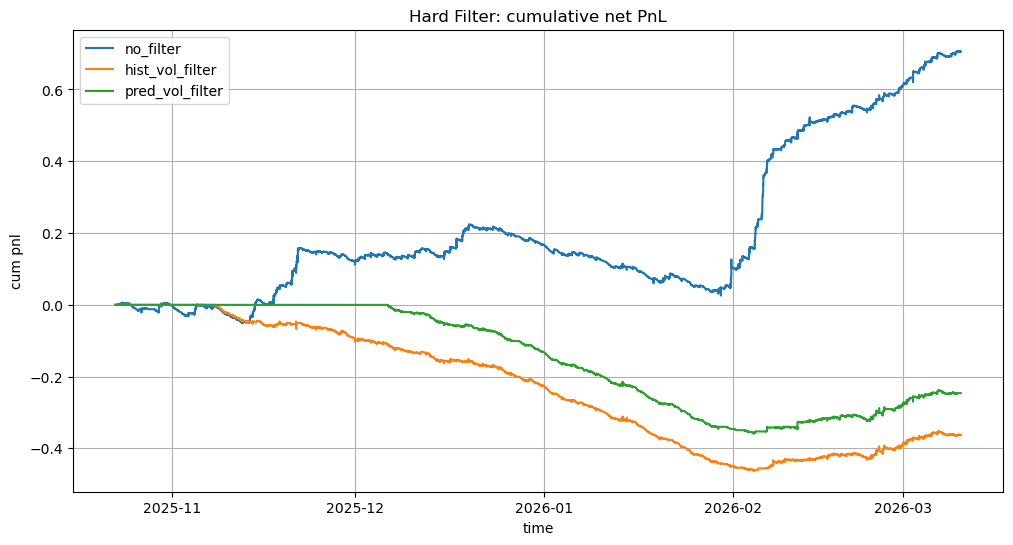

In [18]:
plot_cum_pnl(
    bt_dict,
    pnl_col="net_pnl",
    title="Hard Filter: cumulative net PnL"
)

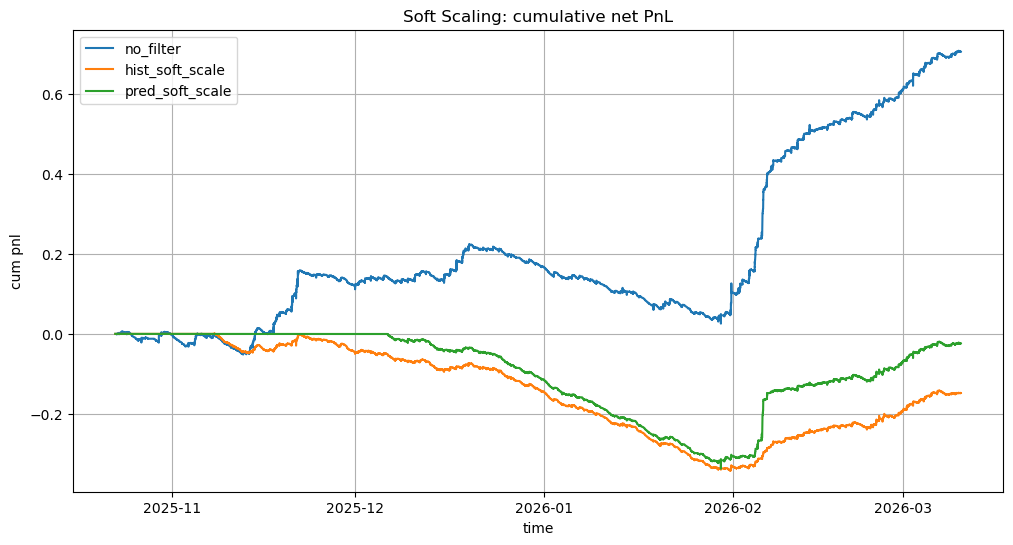

In [19]:
bt_plot_scale = {
    "no_filter": bt_dict["no_filter"],
    "hist_soft_scale": bt_scale_hist,
    "pred_soft_scale": bt_scale_pred,
}

plot_cum_pnl(
    bt_plot_scale,
    pnl_col="net_pnl",
    title="Soft Scaling: cumulative net PnL"
)

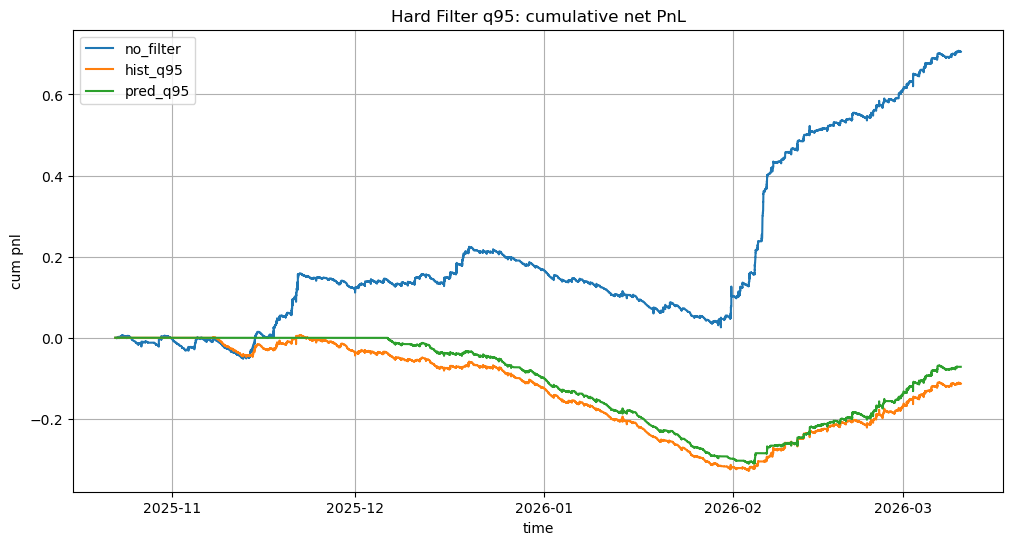

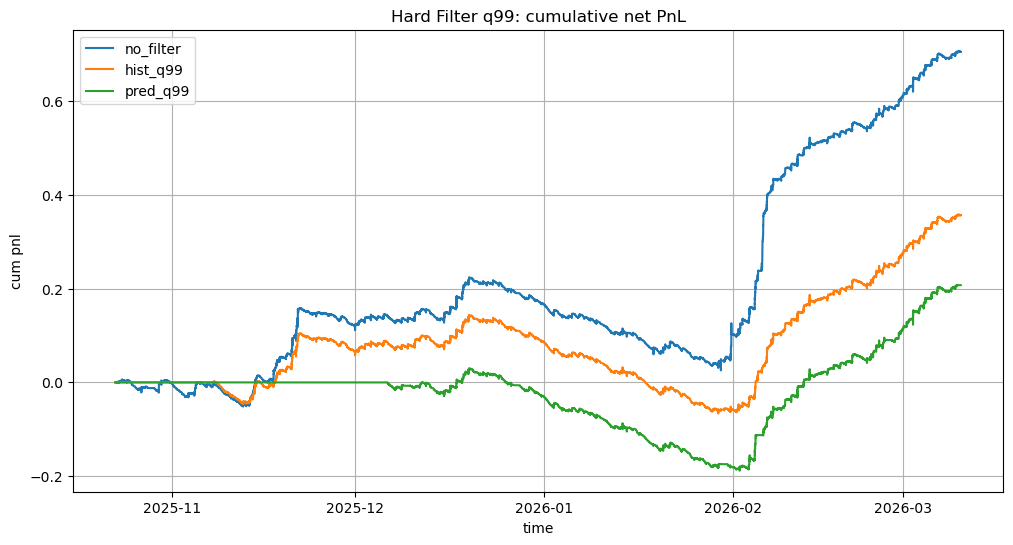

In [20]:
plot_cum_pnl(
    {
        "no_filter": bt_dict_q95["no_filter"],
        "hist_q95": bt_dict_q95["hist_vol_filter"],
        "pred_q95": bt_dict_q95["pred_vol_filter"],
    },
    pnl_col="net_pnl",
    title="Hard Filter q95: cumulative net PnL"
)

plot_cum_pnl(
    {
        "no_filter": bt_dict_q99["no_filter"],
        "hist_q99": bt_dict_q99["hist_vol_filter"],
        "pred_q99": bt_dict_q99["pred_vol_filter"],
    },
    pnl_col="net_pnl",
    title="Hard Filter q99: cumulative net PnL"
)

## High-vol-only regime

The previous sections treated high volatility as something to suppress.

Now we test the opposite idea:

> maybe the strategy should only trade in high-volatility regimes.

This is a much more important conceptual shift.

Instead of using volatility as a brake, we use it as a gate:

- only allow new entries when volatility is above a rolling threshold

In [21]:
import numpy as np
import pandas as pd


def run_basis_zscore_strategy_high_vol_only(
    df: pd.DataFrame,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    vol_signal_col: str = "pred_vol_spot_30m",
    vol_filter_quantile: float = 0.90,
    vol_filter_lookback_min: int = 30 * 24 * 60,
) -> pd.DataFrame:
    """
    只在高 vol regime 允许开仓：
      allow_entry = 1{ vol_t >= rolling_q(vol) }

    position:
      +1 = long futures / short spot
      -1 = short futures / long spot
       0 = flat
    """
    out = df.copy().sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)

    # basis z-score
    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    # rolling vol threshold
    VW = int(round(vol_filter_lookback_min / freq_min))
    out["vol_filter_threshold"] = (
        out[vol_signal_col]
        .rolling(VW, min_periods=max(100, int(0.5 * VW)))
        .quantile(vol_filter_quantile)
        .shift(1)
    )

    # 和之前相反：高 vol 才允许开仓
    out["allow_entry"] = (out[vol_signal_col] >= out["vol_filter_threshold"]).astype(float)
    out.loc[out["vol_filter_threshold"].isna(), "allow_entry"] = 0.0

    # state machine
    pos = np.zeros(len(out), dtype=float)

    for i in range(1, len(out)):
        prev_pos = pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            pos[i] = prev_pos
            continue

        # exit first
        if prev_pos == 1 and abs(z) < exit_z:
            prev_pos = 0
        elif prev_pos == -1 and abs(z) < exit_z:
            prev_pos = 0

        # entry only when flat
        if prev_pos == 0:
            allow_entry = bool(out.at[i, "allow_entry"])
            if allow_entry:
                if z > entry_z:
                    prev_pos = -1
                elif z < -entry_z:
                    prev_pos = +1

        pos[i] = prev_pos

    out["position"] = pos

    # pnl
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)
    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]

    return out

## High-vol scaling

Instead of suppressing size in high volatility, this section tries the opposite:

- low vol: smaller size
- medium vol: larger size
- high vol: full size
- extreme vol: even larger size

This tests whether high-volatility states are the periods where the mean-reversion edge is strongest.

In [22]:
def build_high_vol_size_multiplier(
    vol_signal: pd.Series,
    freq_min: int = 1,
    lookback_min: int = 30 * 24 * 60,
    q1: float = 0.80,
    q2: float = 0.90,
    q3: float = 0.97,
    size_low: float = 0.3,
    size_mid: float = 0.7,
    size_high: float = 1.0,
    size_extreme: float = 1.3,
) -> pd.Series:
    """
    高 vol 放大仓位：
    - <= q1: 0.3
    - q1~q2: 0.7
    - q2~q3: 1.0
    - > q3:  1.3
    """
    W = int(round(lookback_min / freq_min))
    s = vol_signal.copy()

    q1s = s.rolling(W, min_periods=max(100, int(0.5 * W))).quantile(q1).shift(1)
    q2s = s.rolling(W, min_periods=max(100, int(0.5 * W))).quantile(q2).shift(1)
    q3s = s.rolling(W, min_periods=max(100, int(0.5 * W))).quantile(q3).shift(1)

    mult = pd.Series(np.nan, index=s.index, dtype=float)

    ready = q1s.notna() & q2s.notna() & q3s.notna()
    mult.loc[ready] = size_low
    mult.loc[ready & (s > q1s)] = size_mid
    mult.loc[ready & (s > q2s)] = size_high
    mult.loc[ready & (s > q3s)] = size_extreme

    return mult


def run_basis_zscore_strategy_high_vol_scaling(
    df: pd.DataFrame,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    scale_col: str = "pred_vol_spot_30m",
    scale_lookback_min: int = 30 * 24 * 60,
    q1: float = 0.80,
    q2: float = 0.90,
    q3: float = 0.97,
) -> pd.DataFrame:
    """
    basis signal 不变，但高 vol 时放大仓位
    """
    out = df.copy().sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)

    # basis z-score
    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    # raw direction
    pos = np.zeros(len(out), dtype=float)
    for i in range(1, len(out)):
        prev_pos = pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            pos[i] = prev_pos
            continue

        if prev_pos == 1 and abs(z) < exit_z:
            prev_pos = 0
        elif prev_pos == -1 and abs(z) < exit_z:
            prev_pos = 0

        if prev_pos == 0:
            if z > entry_z:
                prev_pos = -1
            elif z < -entry_z:
                prev_pos = +1

        pos[i] = prev_pos

    out["raw_position"] = pos

    mult = build_high_vol_size_multiplier(
        out[scale_col],
        freq_min=freq_min,
        lookback_min=scale_lookback_min,
        q1=q1, q2=q2, q3=q3,
        size_low=0.3,
        size_mid=0.7,
        size_high=1.0,
        size_extreme=1.3,
    )

    out["size_multiplier"] = mult.fillna(0.0)
    out["position"] = out["raw_position"] * out["size_multiplier"]

    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)
    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]

    return out

In [23]:
bt_high_pred_q90 = run_basis_zscore_strategy_high_vol_only(
    df_all,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    vol_signal_col="pred_vol_spot_30m",
    vol_filter_quantile=0.90,
    vol_filter_lookback_min=30 * 24 * 60,
)

bt_high_pred_q80 = run_basis_zscore_strategy_high_vol_only(
    df_all,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    vol_signal_col="pred_vol_spot_30m",
    vol_filter_quantile=0.80,
    vol_filter_lookback_min=30 * 24 * 60,
)

summary_high_only = pd.DataFrame({
    "no_filter": summarize_backtest(bt_dict["no_filter"], freq_min=1),
    "pred_high_only_q80": summarize_backtest(bt_high_pred_q80, freq_min=1),
    "pred_high_only_q90": summarize_backtest(bt_high_pred_q90, freq_min=1),
}).T

print(summary_high_only)

                     ann_ret   ann_vol     sharpe  cum_net_pnl
no_filter           1.885574  0.234951   8.025395     0.705279
pred_high_only_q80  2.317253  0.178997  12.945767     0.866743
pred_high_only_q90  2.084495  0.169925  12.267183     0.779683


In [24]:
bt_high_scale_pred = run_basis_zscore_strategy_high_vol_scaling(
    df_all,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    scale_col="pred_vol_spot_30m",
    scale_lookback_min=30 * 24 * 60,
    q1=0.80,
    q2=0.90,
    q3=0.97,
)

summary_high_scale = pd.DataFrame({
    "no_filter": summarize_backtest(bt_dict["no_filter"], freq_min=1),
    "pred_high_scale": summarize_backtest(bt_high_scale_pred, freq_min=1),
}).T

print(summary_high_scale)

                  ann_ret   ann_vol     sharpe  cum_net_pnl
no_filter        1.885574  0.234951   8.025395     0.705279
pred_high_scale  2.162531  0.211499  10.224795     0.808871


## Final cumulative PnL comparison

The final plots compare the two "high-vol as opportunity" interpretations:

1. **High-vol only**: trade only in high-volatility regimes  
2. **High-vol scaling**: keep trading, but size up in high-volatility regimes  

These are the most important comparisons in the notebook, because they test the central alternative hypothesis:

> predicted volatility may be more useful as a regime-activation signal than as a suppression filter

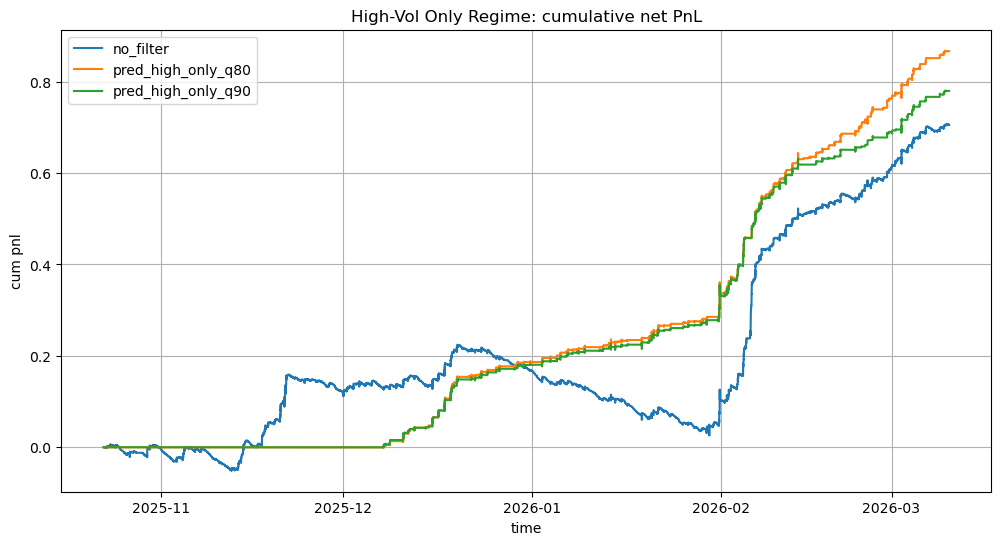

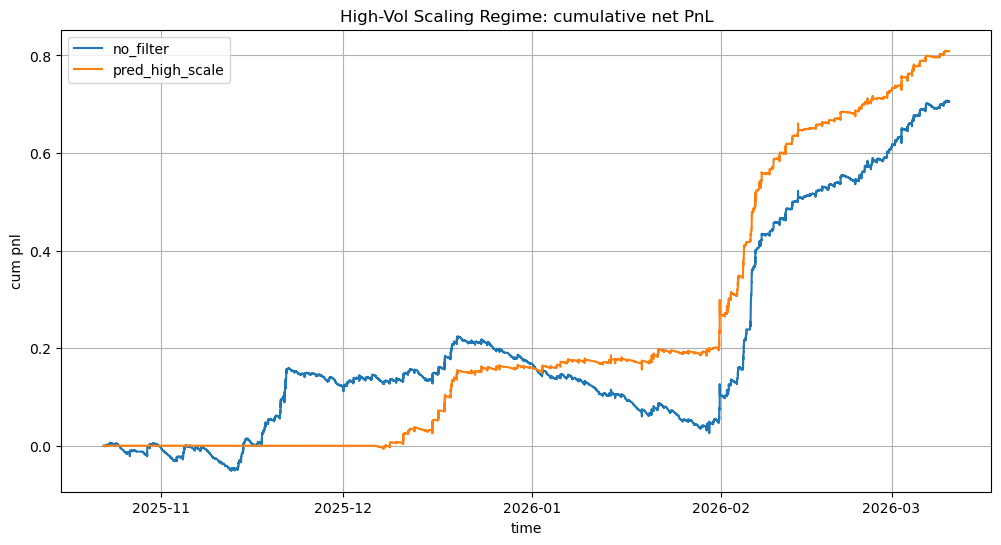

In [26]:
plot_cum_pnl(
    {
        "no_filter": bt_dict["no_filter"],
        "pred_high_only_q80": bt_high_pred_q80,
        "pred_high_only_q90": bt_high_pred_q90,
    },
    pnl_col="net_pnl",
    title="High-Vol Only Regime: cumulative net PnL"
)

plot_cum_pnl(
    {
        "no_filter": bt_dict["no_filter"],
        "pred_high_scale": bt_high_scale_pred,
    },
    pnl_col="net_pnl",
    title="High-Vol Scaling Regime: cumulative net PnL"
)

## Final takeaways

### What this notebook shows

- A simple hard filter treats volatility as something dangerous.
- Soft scaling still keeps that same intuition.
- But the decile analysis suggests volatility may also carry opportunity information.
- The high-vol-only and high-vol-scaling variants test that alternative framing directly.

### Main interpretation

For this strategy, predicted volatility is not necessarily best used as:

- "high vol => trade less"

It may be better used as:

- "high vol => only trade when the market is in the right regime"

That is the central insight of this notebook.